# Demand Planning — Phase 3B Exploration
Auto Components Client | 20 SKUs × 36 Months

**What this notebook covers:**
1. Synthetic dataset — 20 auto-component SKUs × 3 years of monthly actuals
2. Polars — fast in-process DataFrame manipulation
3. DuckDB — SQL-based aggregation and rollups
4. StatsForecast (Nixtla) — AutoETS & AutoARIMA on multiple SKUs
5. HierarchicalForecast — MinTrace reconciliation across Product hierarchy


---
## 1. Synthetic Dataset — 20 Auto Component SKUs × 36 Months

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import duckdb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Product Hierarchy ─────────────────────────────────────────────────────────
# Category → Sub-category → SKU  (mirrors your product_planning Taxonomy)

PRODUCTS = [
    # (sku_code, name, subcategory, category, base_qty, trend, seasonality_amp)
    # BRAKING SYSTEMS
    ('SKU-001', 'Disc Brake Pad Set — Front',     'Brake Pads',    'Braking Systems',   320, 0.8,  0.20),
    ('SKU-002', 'Disc Brake Pad Set — Rear',      'Brake Pads',    'Braking Systems',   280, 0.5,  0.18),
    ('SKU-003', 'Drum Brake Shoe Set',             'Brake Shoes',   'Braking Systems',   180, 0.2,  0.15),
    ('SKU-004', 'Brake Disc Rotor — Front',        'Brake Rotors',  'Braking Systems',   210, 0.6,  0.12),
    ('SKU-005', 'Brake Caliper Assembly',          'Brake Rotors',  'Braking Systems',    95, 1.0,  0.08),
    # FILTRATION
    ('SKU-006', 'Engine Oil Filter',               'Oil Filters',   'Filtration',        450, 1.2,  0.10),
    ('SKU-007', 'Air Filter Element',              'Air Filters',   'Filtration',        380, 1.0,  0.22),
    ('SKU-008', 'Fuel Filter Cartridge',           'Fuel Filters',  'Filtration',        260, 0.7,  0.14),
    ('SKU-009', 'Cabin Air Filter (Pollen)',       'Air Filters',   'Filtration',        190, 1.5,  0.30),
    # SUSPENSION & STEERING
    ('SKU-010', 'Front Strut Assembly',            'Struts',        'Suspension',        120, 0.4,  0.08),
    ('SKU-011', 'Rear Shock Absorber',             'Shocks',        'Suspension',        140, 0.3,  0.07),
    ('SKU-012', 'Ball Joint — Lower Front',        'Joints',        'Suspension',        160, 0.6,  0.10),
    ('SKU-013', 'Tie Rod End Assembly',            'Steering',      'Suspension',        130, 0.5,  0.09),
    # ELECTRICAL
    ('SKU-014', 'Alternator — 80A',               'Alternators',   'Electrical',         75, 0.9,  0.05),
    ('SKU-015', 'Starter Motor Assembly',          'Starters',      'Electrical',         60, 0.8,  0.04),
    ('SKU-016', 'Ignition Coil Pack',              'Ignition',      'Electrical',        200, 1.1,  0.12),
    # DRIVETRAIN
    ('SKU-017', 'CV Axle Shaft — Front Left',     'CV Axles',      'Drivetrain',        110, 0.7,  0.08),
    ('SKU-018', 'CV Axle Shaft — Front Right',    'CV Axles',      'Drivetrain',        108, 0.7,  0.08),
    ('SKU-019', 'Timing Chain Kit',               'Engine Parts',  'Drivetrain',         55, 0.5,  0.06),
    ('SKU-020', 'Serpentine Belt',                'Engine Parts',  'Drivetrain',        310, 1.3,  0.16),
]

# ── Date spine: Jan 2022 – Dec 2024 ──────────────────────────────────────────
months = pd.date_range('2022-01-01', periods=36, freq='MS')
month_idx = np.arange(36)           # 0..35
month_num  = months.month.values    # 1..12 for seasonality

# ── Generate rows ────────────────────────────────────────────────────────────
rows = []
for sku_code, name, subcat, cat, base, trend_monthly, seas_amp in PRODUCTS:
    for i, ds in enumerate(months):
        trend_factor   = 1 + (trend_monthly / 100) * i
        # Seasonality: peak in Mar-Apr (quarter-end service surge) and Oct-Nov (winter prep)
        seas_angle     = 2 * np.pi * month_num[i] / 12
        seas_factor    = 1 + seas_amp * np.sin(seas_angle - np.pi / 6)
        noise          = np.random.normal(1.0, 0.06)
        qty            = max(1, int(base * trend_factor * seas_factor * noise))
        rows.append({
            'ds'          : ds,
            'sku_code'    : sku_code,
            'sku_name'    : name,
            'subcategory' : subcat,
            'category'    : cat,
            'qty'         : qty,
            'unit_price'  : round(np.random.uniform(180, 4500), 2),  # INR
        })

df_pd = pd.DataFrame(rows)
df_pd['revenue'] = (df_pd['qty'] * df_pd['unit_price']).round(2)

print(f"Dataset shape: {df_pd.shape}")
print(f"Date range  : {df_pd['ds'].min().date()} → {df_pd['ds'].max().date()}")
df_pd.head(10)

Dataset shape: (720, 8)
Date range  : 2022-01-01 → 2024-12-01


,ds,sku_code,sku_name,subcategory,category,qty,unit_price,revenue
0,2022-01-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,329,3342.21,1099587.09
1,2022-02-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,351,2766.20,970936.20
2,2022-03-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,376,430.92,162025.92
3,2022-04-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,387,3921.88,1517767.56
4,2022-05-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,424,268.93,114026.32
5,2022-06-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,382,4370.01,1669343.82
6,2022-07-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,325,965.48,313781.00
7,2022-08-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,314,972.31,305305.34
8,2022-09-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,285,2046.00,583110.00
9,2022-10-01,SKU-001,Disc Brake Pad Set — Front,Brake Pads,Braking Systems,242,1438.11,348022.62


In [2]:
# Quick pivot — monthly qty per SKU (first 6 SKUs)
pivot = df_pd.pivot_table(index='ds', columns='sku_code', values='qty')
print("Monthly Qty — first 6 SKUs")
pivot.iloc[:, :6].to_string()

Monthly Qty — first 6 SKUs


'sku_code    SKU-001  SKU-002  SKU-003  SKU-004  SKU-005  SKU-006\nds                                                              \n2022-01-01    329.0    265.0    192.0    217.0     90.0    449.0\n2022-02-01    351.0    301.0    202.0    212.0     99.0    481.0\n2022-03-01    376.0    317.0    221.0    219.0    106.0    517.0\n2022-04-01    387.0    331.0    190.0    246.0    111.0    506.0\n2022-05-01    424.0    346.0    192.0    234.0    102.0    537.0\n2022-06-01    382.0    338.0    188.0    239.0     99.0    525.0\n2022-07-01    325.0    294.0    165.0    223.0     93.0    520.0\n2022-08-01    314.0    253.0    169.0    204.0    102.0    463.0\n2022-09-01    285.0    245.0    150.0    187.0    107.0    459.0\n2022-10-01    242.0    262.0    170.0    177.0    101.0    445.0\n2022-11-01    268.0    249.0    152.0    202.0    104.0    437.0\n2022-12-01    319.0    263.0    166.0    194.0     96.0    544.0\n2023-01-01    381.0    292.0    193.0    213.0    109.0    550.0\n2023-02-0

---
## 2. Polars — Fast In-Process DataFrames
Polars will be your workhorse for building the SKU × Customer × Month tensor before feeding StatsForecast.

In [3]:
# Convert to Polars
df = pl.from_pandas(df_pd)
print(df.schema)
df.head(5)

Schema({'ds': Datetime(time_unit='ns', time_zone=None), 'sku_code': String, 'sku_name': String, 'subcategory': String, 'category': String, 'qty': Int64, 'unit_price': Float64, 'revenue': Float64})


ds,sku_code,sku_name,subcategory,category,qty,unit_price,revenue
datetime[ns],str,str,str,str,i64,f64,f64
2022-01-01 00:00:00,"""SKU-001""","""Disc Brake Pad Set — Front""","""Brake Pads""","""Braking Systems""",329,3342.21,1.0996e6
2022-02-01 00:00:00,"""SKU-001""","""Disc Brake Pad Set — Front""","""Brake Pads""","""Braking Systems""",351,2766.2,970936.2
2022-03-01 00:00:00,"""SKU-001""","""Disc Brake Pad Set — Front""","""Brake Pads""","""Braking Systems""",376,430.92,162025.92
2022-04-01 00:00:00,"""SKU-001""","""Disc Brake Pad Set — Front""","""Brake Pads""","""Braking Systems""",387,3921.88,1.5178e6
2022-05-01 00:00:00,"""SKU-001""","""Disc Brake Pad Set — Front""","""Brake Pads""","""Braking Systems""",424,268.93,114026.32


In [4]:
# ── Category-level monthly rollup ─────────────────────────────────────────────
cat_monthly = (
    df
    .group_by(['category', 'ds'])
    .agg([
        pl.sum('qty').alias('total_qty'),
        pl.sum('revenue').alias('total_revenue'),
    ])
    .sort(['category', 'ds'])
)
print("Category × Month rollup:")
cat_monthly.head(12)

Category × Month rollup:


category,ds,total_qty,total_revenue
str,datetime[ns],i64,f64
"""Braking Systems""",2022-01-01 00:00:00,1093,2.6954e6
"""Braking Systems""",2022-02-01 00:00:00,1165,2.9974e6
"""Braking Systems""",2022-03-01 00:00:00,1239,2.4251e6
"""Braking Systems""",2022-04-01 00:00:00,1265,3677414.1
"""Braking Systems""",2022-05-01 00:00:00,1298,1.8889e6
…,…,…,…
"""Braking Systems""",2022-08-01 00:00:00,1042,2.2540e6
"""Braking Systems""",2022-09-01 00:00:00,974,2.7489e6
"""Braking Systems""",2022-10-01 00:00:00,952,1.4111e6


In [5]:
# ── 12-month trailing average per SKU (useful as a naive baseline) ────────────
trailing_avg = (
    df
    .sort('ds')
    .group_by('sku_code')
    .agg([
        pl.col('qty').tail(12).mean().alias('trailing_12m_avg_qty'),
        pl.col('revenue').tail(12).mean().alias('trailing_12m_avg_rev'),
        pl.col('sku_name').first(),
        pl.col('category').first(),
    ])
    .sort('trailing_12m_avg_qty', descending=True)
)
print("Trailing 12-month avg qty per SKU (descending):")
trailing_avg

Trailing 12-month avg qty per SKU (descending):


sku_code,trailing_12m_avg_qty,trailing_12m_avg_rev,sku_name,category
str,f64,f64,str,str
"""SKU-006""",597.0,1.4530e6,"""Engine Oil Filter""","""Filtration"""
"""SKU-007""",507.666667,1.1389e6,"""Air Filter Element""","""Filtration"""
"""SKU-020""",423.833333,881636.311667,"""Serpentine Belt""","""Drivetrain"""
"""SKU-001""",399.416667,701524.619167,"""Disc Brake Pad Set — Front""","""Braking Systems"""
"""SKU-002""",318.583333,572823.41,"""Disc Brake Pad Set — Rear""","""Braking Systems"""
…,…,…,…,…
"""SKU-018""",134.0,282860.028333,"""CV Axle Shaft — Front Right""","""Drivetrain"""
"""SKU-005""",122.666667,338054.4925,"""Brake Caliper Assembly""","""Braking Systems"""
"""SKU-014""",96.5,249484.7675,"""Alternator — 80A""","""Electrical"""


In [6]:
# ── Year-over-year growth by category ─────────────────────────────────────────
df_with_year = df.with_columns(pl.col('ds').dt.year().alias('year'))

yoy = (
    df_with_year
    .group_by(['category', 'year'])
    .agg(pl.sum('qty').alias('total_qty'))
    .sort(['category', 'year'])
    .with_columns(
        pl.col('total_qty').shift(1).over('category').alias('prev_year_qty')
    )
    .with_columns(
        ((pl.col('total_qty') - pl.col('prev_year_qty')) / pl.col('prev_year_qty') * 100)
        .round(1)
        .alias('yoy_growth_pct')
    )
    .filter(pl.col('year') > 2022)
)
print("YoY Growth % by Category:")
yoy

YoY Growth % by Category:


category,year,total_qty,prev_year_qty,yoy_growth_pct
str,i32,i64,i64,f64
"""Braking Systems""",2023,14353,13387,7.2
"""Braking Systems""",2024,15341,14353,6.9
"""Drivetrain""",2023,8207,7301,12.4
"""Drivetrain""",2024,9042,8207,10.2
"""Electrical""",2023,4780,4195,13.9
"""Electrical""",2024,5119,4780,7.1
"""Filtration""",2023,18225,16376,11.3
"""Filtration""",2024,20190,18225,10.8
"""Suspension""",2023,7077,6686,5.8


---
## 3. DuckDB — SQL Rollups Without Loading Full Tables
In your Django Celery tasks, DuckDB will query Postgres-exported Parquet files (or in-memory frames) for hierarchical aggregation.

In [7]:
# Register the Polars frame directly — zero-copy via Arrow
con = duckdb.connect()
con.register('actuals', df.to_arrow())

# ── Q1: Best-selling SKU per category (full 3-year period) ────────────────────
print("=== Best-selling SKU per category ===")
con.execute("""
    SELECT category, sku_code, sku_name, SUM(qty) AS total_qty
    FROM actuals
    GROUP BY category, sku_code, sku_name
    QUALIFY RANK() OVER (PARTITION BY category ORDER BY SUM(qty) DESC) = 1
    ORDER BY total_qty DESC
""").df()

=== Best-selling SKU per category ===


,category,sku_code,sku_name,total_qty
0,Filtration,SKU-006,Engine Oil Filter,19602.0
1,Drivetrain,SKU-020,Serpentine Belt,13528.0
2,Braking Systems,SKU-001,Disc Brake Pad Set — Front,13099.0
3,Electrical,SKU-016,Ignition Coil Pack,8443.0
4,Suspension,SKU-012,Ball Joint — Lower Front,6274.0


In [8]:
# ── Q2: Monthly seasonality index per SKU (avg_month / overall_avg) ──────────
print("=== Seasonality Index — SKU-001 ===")
con.execute("""
    WITH monthly_avg AS (
        SELECT sku_code,
               MONTH(ds) AS month_num,
               AVG(qty)  AS avg_qty_month
        FROM actuals
        WHERE sku_code = 'SKU-001'
        GROUP BY sku_code, MONTH(ds)
    ),
    overall AS (
        SELECT sku_code, AVG(qty) AS avg_qty_overall
        FROM actuals
        WHERE sku_code = 'SKU-001'
        GROUP BY sku_code
    )
    SELECT m.month_num,
           ROUND(m.avg_qty_month, 1)                                    AS avg_qty,
           ROUND(m.avg_qty_month / o.avg_qty_overall, 3)                AS seasonality_index
    FROM monthly_avg m JOIN overall o USING (sku_code)
    ORDER BY month_num
""").df()

=== Seasonality Index — SKU-001 ===


,month_num,avg_qty,seasonality_index
0,1,369.3,1.015
1,2,386.7,1.063
2,3,409.7,1.126
3,4,425.7,1.170
4,5,426.0,1.171
5,6,411.7,1.131
6,7,364.7,1.002
7,8,325.0,0.893
8,9,308.3,0.847
9,10,284.7,0.782


In [9]:
# ── Q3: Hierarchical rollup (GROUPING SETS) in one SQL pass ───────────────────
# This is the kind of query you'll run in Celery tasks before feeding StatsForecast
print("=== Hierarchical Rollup (Category / Subcategory / SKU) for 2024 ===")
con.execute("""
    SELECT
        COALESCE(category,    '(ALL)') AS category,
        COALESCE(subcategory, '(ALL)') AS subcategory,
        COALESCE(sku_code,    '(ALL)') AS sku_code,
        SUM(qty)     AS total_qty,
        ROUND(SUM(revenue), 0) AS total_revenue_inr
    FROM actuals
    WHERE YEAR(ds) = 2024
    GROUP BY GROUPING SETS (
        (),
        (category),
        (category, subcategory),
        (category, subcategory, sku_code)
    )
    ORDER BY category, subcategory, sku_code
""").df()

=== Hierarchical Rollup (Category / Subcategory / SKU) for 2024 ===


,category,subcategory,sku_code,total_qty,total_revenue_inr
0,(ALL),(ALL),(ALL),57139.0,124339177.0
1,Braking Systems,(ALL),(ALL),15341.0,30744803.0
2,Braking Systems,Brake Pads,(ALL),8616.0,15292176.0
3,Braking Systems,Brake Pads,SKU-001,4793.0,8418295.0
4,Braking Systems,Brake Pads,SKU-002,3823.0,6873881.0
5,Braking Systems,Brake Rotors,(ALL),4397.0,9761000.0
6,Braking Systems,Brake Rotors,SKU-004,2925.0,5704346.0
7,Braking Systems,Brake Rotors,SKU-005,1472.0,4056654.0
8,Braking Systems,Brake Shoes,(ALL),2328.0,5691627.0
9,Braking Systems,Brake Shoes,SKU-003,2328.0,5691627.0


---
## 4. StatsForecast — AutoETS & AutoARIMA on Multiple SKUs
StatsForecast's key advantage: it fits **all 20 SKUs in one vectorised call** via Numba, not a Python loop.

In [10]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, CrostonSBA, SeasonalNaive
from statsforecast.utils import ConformalIntervals

# StatsForecast expects a DataFrame with columns: unique_id, ds, y
sf_df = df_pd[['sku_code', 'ds', 'qty']].rename(columns={'sku_code': 'unique_id', 'qty': 'y'})
sf_df['ds'] = pd.to_datetime(sf_df['ds'])

print(f"Input shape : {sf_df.shape}")
print(f"Series count: {sf_df['unique_id'].nunique()}")
sf_df.head(6)


Input shape : (720, 3)
Series count: 20


,unique_id,ds,y
0,SKU-001,2022-01-01,329
1,SKU-001,2022-02-01,351
2,SKU-001,2022-03-01,376
3,SKU-001,2022-04-01,387
4,SKU-001,2022-05-01,424
5,SKU-001,2022-06-01,382


In [11]:
# Fit 4 models on all 20 SKUs simultaneously
# season_length=12 → monthly data with annual seasonality
sf = StatsForecast(
    models=[
        AutoETS(season_length=12),
        AutoARIMA(season_length=12),
        SeasonalNaive(season_length=12),      # simple seasonal baseline
        CrostonSBA(),                          # good for intermittent / lumpy demand
    ],
    freq='MS',          # Month Start
    n_jobs=-1,          # use all CPU cores
)

# forecast 6 months ahead (Jan–Jun 2025) with 80% and 95% prediction intervals
forecast_df = sf.forecast(
    df=sf_df, h=6,
    prediction_intervals=ConformalIntervals(h=6, n_windows=2),
    level=[80, 95]
)
print(f"Forecast shape: {forecast_df.shape}")
forecast_df.head(12)


Forecast shape: (120, 22)


,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,...,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95,CrostonSBA,CrostonSBA-lo-95,CrostonSBA-lo-80,CrostonSBA-hi-80,CrostonSBA-hi-95
0,SKU-001,2025-01-01,434.951843,378.252777,379.151123,490.752563,491.650879,433.926331,398.847748,405.218231,...,398.0,360.649994,365.600006,430.399994,435.350006,355.657318,282.978424,292.022308,419.292328,428.336212
1,SKU-001,2025-02-01,452.292603,344.468567,350.991882,553.593323,560.116638,453.324768,401.648102,411.569458,...,426.0,383.149994,383.600006,468.399994,468.850006,355.657318,258.428192,277.821381,433.493256,452.886444
2,SKU-001,2025-03-01,475.233826,335.084778,343.633087,606.834534,615.382874,476.371033,403.442749,412.884766,...,450.0,406.225006,415.899994,484.100006,493.774994,355.657318,233.753189,251.121399,460.193237,477.561432
3,SKU-001,2025-04-01,491.335571,366.311523,369.234863,613.436279,616.359619,490.963654,407.337158,420.894958,...,458.0,402.399994,409.600006,506.399994,513.599976,355.657318,227.628189,250.621399,460.693237,483.686432
4,SKU-001,2025-05-01,491.802734,388.028687,388.702026,594.903442,595.576782,484.942902,403.085236,413.050598,...,446.0,377.475006,384.899994,507.100006,514.525024,355.657318,240.378189,265.621399,445.693237,470.936432
5,SKU-001,2025-06-01,477.507690,364.802338,374.704010,580.311340,590.213013,480.107574,376.186340,398.086090,...,461.0,393.875000,399.500000,522.500000,528.125000,355.657318,225.828415,252.422302,458.892334,485.486206
6,SKU-002,2025-01-01,308.504852,250.077530,263.803619,353.206116,366.932220,300.958344,265.440765,270.888000,...,286.0,265.200012,268.799988,303.200012,306.799988,290.123901,271.765503,273.763855,306.483978,308.482330
7,SKU-002,2025-02-01,347.639130,294.236481,296.036591,399.241638,401.041779,348.958344,324.019379,325.869415,...,334.0,332.000000,332.000000,336.000000,336.000000,290.123901,235.589844,246.416489,333.831329,344.657959
8,SKU-002,2025-03-01,360.166748,286.314575,286.764465,433.569000,434.018890,376.958344,331.556854,340.005859,...,362.0,329.524994,331.100006,392.899994,394.475006,290.123901,208.339844,221.416489,358.831329,371.907959
9,SKU-002,2025-04-01,377.336761,285.534637,298.134491,456.539062,469.138916,398.958344,331.162415,337.031708,...,384.0,326.424988,330.700012,437.299988,441.575012,290.123901,189.793518,213.231201,367.016602,390.454285


In [12]:
# ── Cross-validation — rolling origin, 3 windows of 3 months ─────────────────
# This is how you'd compute MAPE/WMAPE for model selection in your ForecastAccuracy model
cv_df = sf.cross_validation(
    df=sf_df,
    h=3,            # horizon
    n_windows=3,    # 3 rolling origins
    step_size=3,
)

# Compute MAPE per model
models_cols = ['AutoETS', 'AutoARIMA', 'SeasonalNaive', 'CrostonSBA']
mape_rows = []
for model in models_cols:
    if model in cv_df.columns:
        ape = (cv_df[model] - cv_df['y']).abs() / cv_df['y'].replace(0, np.nan) * 100
        mape_rows.append({'model': model, 'MAPE': round(ape.mean(), 2)})

mape_df = pd.DataFrame(mape_rows).sort_values('MAPE')
print("\nModel MAPE comparison (lower is better):")
mape_df


Model MAPE comparison (lower is better):


,model,MAPE
1,AutoARIMA,7.60
2,SeasonalNaive,8.97
0,AutoETS,9.79
3,CrostonSBA,11.32


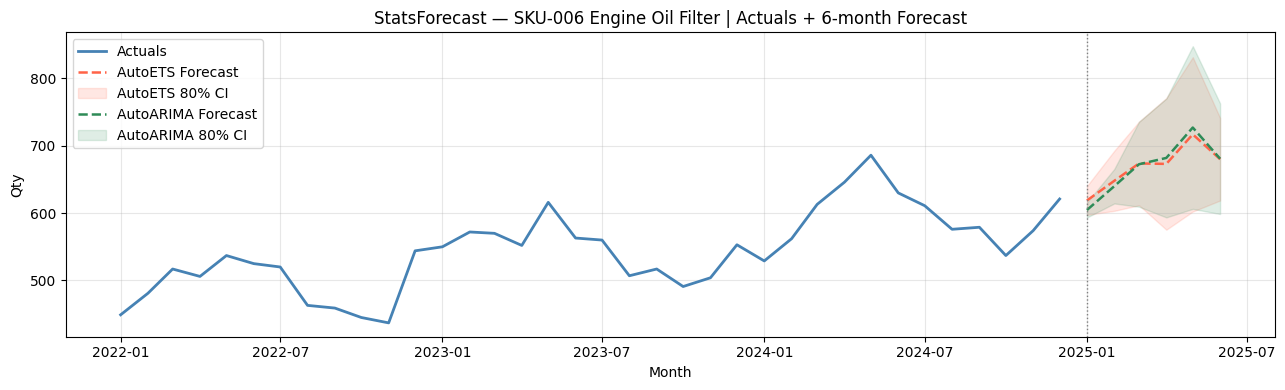

In [13]:
# ── Forecast for a single SKU with prediction intervals ───────────────────────
import matplotlib.pyplot as plt

sku = 'SKU-006'   # Engine Oil Filter — high volume, clear trend

hist    = sf_df[sf_df['unique_id'] == sku].set_index('ds')
fcast   = forecast_df[forecast_df['unique_id'] == sku].set_index('ds')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist.index, hist['y'], label='Actuals', color='steelblue', linewidth=2)

for model, color in [('AutoETS', 'tomato'), ('AutoARIMA', 'seagreen')]:
    if model in fcast.columns:
        ax.plot(fcast.index, fcast[model], label=f'{model} Forecast',
                color=color, linewidth=1.8, linestyle='--')
        lo, hi = f'{model}-lo-80', f'{model}-hi-80'
        if lo in fcast.columns:
            ax.fill_between(fcast.index, fcast[lo], fcast[hi],
                            alpha=0.15, color=color, label=f'{model} 80% CI')

ax.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=1)
ax.set_title(f'StatsForecast — {sku} Engine Oil Filter | Actuals + 6-month Forecast')
ax.set_xlabel('Month'); ax.set_ylabel('Qty')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. HierarchicalForecast — MinTrace Reconciliation
This is the core of your demand planning module: forecasts at SKU level must **add up correctly** to subcategory and category forecasts. MinTrace ensures that mathematically.

In [14]:
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

# Build the hierarchy spec: list of [level] lists top-down
# Mirrors your Taxonomy: category → subcategory → sku_code
hier_spec = [
    ['category'],
    ['category', 'subcategory'],
    ['category', 'subcategory', 'sku_code'],
]

# aggregate() needs: ds, [hierarchy cols], y (target named 'y')
raw = df_pd[['ds', 'category', 'subcategory', 'sku_code', 'qty']].copy()
raw = raw.rename(columns={'qty': 'y'})
raw['ds'] = pd.to_datetime(raw['ds'])
raw['y'] = raw['y'].astype(float)

# aggregate() returns:
#  Y_df : long DataFrame (unique_id, ds, y) covering ALL hierarchy nodes
#  S_df : summing matrix — maps bottom-level SKUs to all aggregates
#  tags : dict mapping level name → array of node names at that level
Y_df, S_df, tags = aggregate(raw, hier_spec)

print(f"Y_df shape (all nodes × 36 months, long): {Y_df.shape}")
print(f"S_df shape (all nodes × leaf SKUs):        {S_df.shape}")
print(f"Hierarchy levels: {list(tags.keys())}")
print(f"Sample nodes: {Y_df['unique_id'].unique()[:8].tolist()}")
S_df.head()


Y_df shape (all nodes × 36 months, long): (1440, 3)
S_df shape (all nodes × leaf SKUs):        (40, 21)
Hierarchy levels: ['category', 'category/subcategory', 'category/subcategory/sku_code']
Sample nodes: ['Braking Systems', 'Drivetrain', 'Electrical', 'Filtration', 'Suspension', 'Braking Systems/Brake Pads', 'Braking Systems/Brake Rotors', 'Braking Systems/Brake Shoes']


,unique_id,Braking Systems/Brake Pads/SKU-001,Braking Systems/Brake Pads/SKU-002,Braking Systems/Brake Rotors/SKU-004,Braking Systems/Brake Rotors/SKU-005,Braking Systems/Brake Shoes/SKU-003,Drivetrain/CV Axles/SKU-017,Drivetrain/CV Axles/SKU-018,Drivetrain/Engine Parts/SKU-019,Drivetrain/Engine Parts/SKU-020,...,Electrical/Ignition/SKU-016,Electrical/Starters/SKU-015,Filtration/Air Filters/SKU-007,Filtration/Air Filters/SKU-009,Filtration/Fuel Filters/SKU-008,Filtration/Oil Filters/SKU-006,Suspension/Joints/SKU-012,Suspension/Shocks/SKU-011,Suspension/Steering/SKU-013,Suspension/Struts/SKU-010
0,Braking Systems,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Drivetrain,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Electrical,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Filtration,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,Suspension,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [15]:
# Y_df from aggregate() is already in long format (unique_id, ds, y)
# It covers ALL nodes: top-level categories, subcategories, and leaf SKUs
Y_long = Y_df.copy()

print(f"Long format shape: {Y_long.shape}")
print(f"Total series (nodes): {Y_long['unique_id'].nunique()}")
Y_long.head(8)


Long format shape: (1440, 3)
Total series (nodes): 40


,unique_id,ds,y
0,Braking Systems,2022-01-01,1093.0
1,Braking Systems,2022-02-01,1165.0
2,Braking Systems,2022-03-01,1239.0
3,Braking Systems,2022-04-01,1265.0
4,Braking Systems,2022-05-01,1298.0
5,Braking Systems,2022-06-01,1246.0
6,Braking Systems,2022-07-01,1100.0
7,Braking Systems,2022-08-01,1042.0


In [16]:
# Fit StatsForecast on ALL hierarchy nodes (SKUs + aggregates)
sf_hier = StatsForecast(
    models=[AutoETS(season_length=12), SeasonalNaive(season_length=12)],
    freq='MS',
    n_jobs=-1,
)

# Forecasts WITH prediction intervals — needed for MinTrace WLS residual weighting
forecasts_df = sf_hier.forecast(
    df=Y_long, h=6,
    fitted=True,
    prediction_intervals=ConformalIntervals(h=6, n_windows=2),
    level=[80, 95]
)
print(f"Base forecasts shape: {forecasts_df.shape}")
forecasts_df.head(6)


Base forecasts shape: (240, 12)


,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Braking Systems,2025-01-01,1341.469802,1235.415378,1247.278805,1435.660800,1447.524227,1251.0,1192.125,1204.5,1297.5,1309.875
1,Braking Systems,2025-02-01,1426.095813,1245.898439,1284.333018,1567.858608,1606.293187,1334.0,1256.225,1256.9,1411.1,1411.775
2,Braking Systems,2025-03-01,1499.283873,1216.549419,1277.372756,1721.194989,1782.018327,1444.0,1273.775,1300.1,1587.9,1614.225
3,Braking Systems,2025-04-01,1536.215223,1253.417166,1320.049694,1752.380752,1819.013280,1446.0,1340.425,1344.7,1547.3,1551.575
4,Braking Systems,2025-05-01,1566.181906,1285.183859,1345.216418,1787.147394,1847.179953,1442.0,1386.150,1386.6,1497.4,1497.850
5,Braking Systems,2025-06-01,1502.431057,1245.034523,1300.871619,1703.990494,1759.827591,1417.0,1303.750,1306.0,1528.0,1530.250


In [17]:
# In-sample fitted values — used by MinTrace to estimate residual variance per node
fitted_df = sf_hier.forecast_fitted_values()
print(f"Fitted values shape: {fitted_df.shape}")
fitted_df.head(4)


Fitted values shape: (1440, 13)


,unique_id,ds,y,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Braking Systems,2022-01-01,1093.0,1093.041970,1043.041126,1060.348175,1125.735764,1143.042814,NaN,NaN,NaN,NaN,NaN
1,Braking Systems,2022-02-01,1165.0,1163.332631,1113.331787,1130.638836,1196.026425,1213.333475,NaN,NaN,NaN,NaN,NaN
2,Braking Systems,2022-03-01,1239.0,1224.470708,1174.469864,1191.776913,1257.164502,1274.471552,NaN,NaN,NaN,NaN,NaN
3,Braking Systems,2022-04-01,1265.0,1256.391123,1206.390279,1223.697328,1289.084918,1306.391967,NaN,NaN,NaN,NaN,NaN


In [18]:
# ── MinTrace Reconciliation ───────────────────────────────────────────────────
# MinTrace(method='ols')      → Ordinary Least Squares
# MinTrace(method='wls_struct') → Weighted by hierarchy structure (good default)
# BottomUp()                  → Simply aggregate SKU forecasts upward (no revision)

hrec = HierarchicalReconciliation(reconcilers=[
    BottomUp(),
    MinTrace(method='ols'),
    MinTrace(method='wls_struct'),
])

reconciled_df = hrec.reconcile(
    Y_hat_df=forecasts_df,
    Y_df=Y_long,
    S_df=S_df,      # note: param is S_df not S in hierarchicalforecast v1.5+
    tags=tags,
)

print(f"Reconciled forecasts shape: {reconciled_df.shape}")
# Columns are suffixed: AutoETS/BottomUp, AutoETS/MinTrace(ols), etc.
reconciled_df.head(6)


Reconciled forecasts shape: (240, 18)


,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95,AutoETS/BottomUp,SeasonalNaive/BottomUp,AutoETS/MinTrace_method-ols,SeasonalNaive/MinTrace_method-ols,AutoETS/MinTrace_method-wls_struct,SeasonalNaive/MinTrace_method-wls_struct
0,Braking Systems,2025-01-01,1341.469802,1235.415378,1247.278805,1435.660800,1447.524227,1251.0,1192.125,1204.5,1297.5,1309.875,1292.712846,1251.0,1322.328263,1251.0,1306.226463,1251.0
1,Braking Systems,2025-02-01,1426.095813,1245.898439,1284.333018,1567.858608,1606.293187,1334.0,1256.225,1256.9,1411.1,1411.775,1349.963182,1334.0,1397.613929,1334.0,1373.057705,1334.0
2,Braking Systems,2025-03-01,1499.283873,1216.549419,1277.372756,1721.194989,1782.018327,1444.0,1273.775,1300.1,1587.9,1614.225,1386.207295,1444.0,1457.948745,1444.0,1421.879678,1444.0
3,Braking Systems,2025-04-01,1536.215223,1253.417166,1320.049694,1752.380752,1819.013280,1446.0,1340.425,1344.7,1547.3,1551.575,1420.254368,1446.0,1493.606903,1446.0,1456.526627,1446.0
4,Braking Systems,2025-05-01,1566.181906,1285.183859,1345.216418,1787.147394,1847.179953,1442.0,1386.150,1386.6,1497.4,1497.850,1429.537934,1442.0,1516.429751,1442.0,1472.925691,1442.0
5,Braking Systems,2025-06-01,1502.431057,1245.034523,1300.871619,1703.990494,1759.827591,1417.0,1303.750,1306.0,1528.0,1530.250,1392.576913,1417.0,1462.167453,1417.0,1427.081928,1417.0


In [19]:
# ── Coherence check: do reconciled SKU forecasts add up to category? ──────────
# Pick AutoETS + MinTrace(ols) column
col = [c for c in reconciled_df.columns if 'MinTrace' in c and 'AutoETS' in c][0]

jan25 = reconciled_df[reconciled_df['ds'] == '2025-01-01'].set_index('unique_id')

braking_skus   = [t for t in jan25.index if 'Braking Systems' in t and '/' not in t.replace('Braking Systems/', '')]
braking_sub_sum = jan25.loc[[t for t in jan25.index if t.startswith('Braking Systems/') and t.count('/') == 1], col].sum()
braking_top     = jan25.loc['Braking Systems', col] if 'Braking Systems' in jan25.index else None

print(f"Jan-2025 Braking Systems — top-level reconciled: {braking_top:.1f}")
print(f"Jan-2025 Braking Systems — sum of sub-categories: {braking_sub_sum:.1f}")
print("✓ Coherent!" if abs(braking_top - braking_sub_sum) < 1 else "✗ Incoherent — check reconciler")

Jan-2025 Braking Systems — top-level reconciled: 1322.3
Jan-2025 Braking Systems — sum of sub-categories: 1322.3
✓ Coherent!


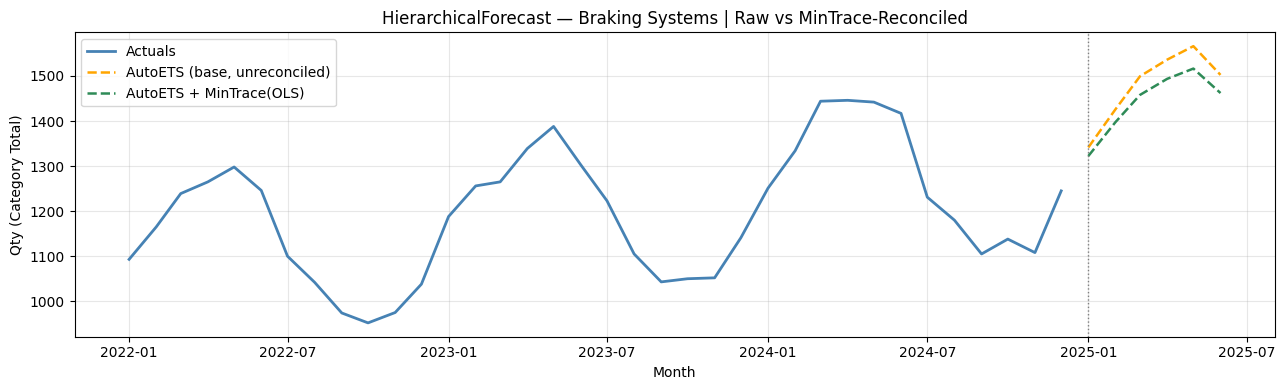

In [20]:
# ── Visual: Raw vs Reconciled forecast at category level ─────────────────────
raw_col  = [c for c in forecasts_df.columns if 'AutoETS' in c and 'lo' not in c and 'hi' not in c][0]
rec_col  = col  # MinTrace OLS

cat_node  = 'Braking Systems'
hist_node = Y_long[Y_long['unique_id'] == cat_node].set_index('ds')['y']
raw_fcast = forecasts_df[forecasts_df['unique_id'] == cat_node].set_index('ds')[raw_col]
rec_fcast = reconciled_df[reconciled_df['unique_id'] == cat_node].set_index('ds')[rec_col]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist_node, label='Actuals', color='steelblue', linewidth=2)
ax.plot(raw_fcast, label='AutoETS (base, unreconciled)', color='orange',  linestyle='--', linewidth=1.8)
ax.plot(rec_fcast, label='AutoETS + MinTrace(OLS)',      color='seagreen', linestyle='--', linewidth=1.8)
ax.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=1)
ax.set_title(f'HierarchicalForecast — {cat_node} | Raw vs MinTrace-Reconciled')
ax.set_xlabel('Month'); ax.set_ylabel('Qty (Category Total)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── MinTrace Reconciliation ───────────────────────────────────────────────────
# MinTrace(method='ols')      → Ordinary Least Squares
# MinTrace(method='wls_struct') → Weighted by hierarchy structure (good default)
# BottomUp()                  → Simply aggregate SKU forecasts upward (no revision)

hrec = HierarchicalReconciliation(reconcilers=[
    BottomUp(),
    MinTrace(method='ols'),
    MinTrace(method='wls_struct'),
])

reconciled_df = hrec.reconcile(
    Y_hat_df=forecasts_df,
    Y_df=Y_long,
    S_df=S_df,      # note: param is S_df not S in hierarchicalforecast v1.5+
    tags=tags,
)

print(f"Reconciled forecasts shape: {reconciled_df.shape}")
# Columns are suffixed: AutoETS/BottomUp, AutoETS/MinTrace(ols), etc.
reconciled_df.head(6)
